# **ST1511 CA2 – Part A: Customer Behavioral Segmentation**

**Name:** Risalat Masrafi  **Admin No:** P2508290  **Class:** DAAA/FT/1B/04



# Project Introduction

## Project Purpose and Scope
As per the ST1511 CA2 requirements, this project implements a comprehensive unsupervised machine learning pipeline to segment a customer base into distinct behavioral personas. By utilizing the **Scikit-Learn library**, we have transitioned from raw demographic observations to a sophisticated multi-dimensional clustering model. This analysis identifies non-obvious patterns in customer behavior, providing a mathematical foundation for understanding how age and income levels drive spending engagement.

## Dataset Description & Variable Analysis
The analysis is performed on a customer dataset consisting of 200 observations. To move beyond simple one-dimensional grouping, the project focuses on a 3D feature set to capture the intersection of life stage and financial capacity:

* **Age:** A demographic variable used to identify generational shifts in behavior.
* **Annual Income ($k$):** The primary measure of a customer's financial capacity and purchasing power.
* **Spending Score (1–100):** A behavioral metric assigned based on historical engagement and purchase patterns.



## Model Validation & Stability Strategy
To ensure that the identified clusters represent natural groupings in the data rather than mathematical artifacts, we employ a multi-layered validation framework:

* **Optimal $k$ Selection:**
    1. **The Elbow Method (WCSS):** Used to identify the "inflection point" where additional clusters yield diminishing returns in error reduction.
    2. **Silhouette Analysis:** Used to measure cluster separation and cohesion; our finalized model achieved a **Silhouette Score of 0.428**, confirming reasonable cluster structure.
* **Dimensionality Reduction for Validation:**
    * **Principal Component Analysis (PCA):** A linear transformation used to project 3D data into 2D while retaining maximum variance, resolving overlaps caused by the Age variable.
    * **t-SNE (t-Distributed Stochastic Neighbor Embedding):** A non-linear visualization technique used to confirm cluster robustness and "island" formation in a non-linear manifold.

## Machine Learning Workflow
The project follows a structured sequence aligned with the 50-mark CA2 evaluation rubric:

### Stage 1: Exploratory Data Analysis (EDA)
We conduct a data audit to ensure zero missing values and zero duplicates (`df.info()`, `df.isnull()`). Univariate and bivariate analyses are performed to understand the distribution of income and spending across the population.

### Stage 2: Data Preprocessing
To prevent features with larger numerical ranges (like Income) from dominating the clustering algorithm, we apply **StandardScaler**. This ensures that Age, Income, and Spending Score are treated with equal mathematical weight.

### Stage 3: Modelling and Evaluation
Using the **K-Means algorithm**, we benchmark different cluster counts. The final model performance is evaluated using the **Silhouette Score** to confirm the mathematical integrity of the $k=6$ solution.

### Stage 4: Dimensionality Reduction & Visualization
We apply **PCA** and **t-SNE** to visualize the 3D clusters in 2D space. This stage is critical for verifying that the clusters remain cohesive and distinct, particularly for the isolated "Middle-Aged, Rich, High Spenders" group identified in the manifold.

### Stage 5: Cluster Profiling & Result Analysis
The final segments are mapped back to their original units to define six simple, informative personas (e.g., **"Middle-Aged, Rich, High Spenders"** vs. **"Old, Low-Income, Low Spenders"**). We analyze the spatial distribution of these groups to provide a definitive map of behavioral archetypes.

# Importing Dependencies and Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import os
os.environ["OMP_NUM_THREADS"] = "1"

import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv('CA2-Customer-Data.csv')
df.head(10)

,CustomerID,Gender,Age,Income (k$),How Much They Spend
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


# Exploratory Data Analysis

In [4]:
print(df.info())
print(df.duplicated().sum())
print(df.isnull().sum())
print(df.nunique())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   CustomerID           200 non-null    int64 
 1   Gender               200 non-null    object
 2   Age                  200 non-null    int64 
 3   Income (k$)          200 non-null    int64 
 4   How Much They Spend  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
0
CustomerID             0
Gender                 0
Age                    0
Income (k$)            0
How Much They Spend    0
dtype: int64
CustomerID             200
Gender                   2
Age                     51
Income (k$)             64
How Much They Spend     84
dtype: int64


## Initial Data Inspection and Quality Assurance

Before proceeding with feature scaling and clustering, a thorough inspection of the dataset was conducted to ensure data integrity. This involved checking the data structure, identifying missing values, and scanning for duplicate entries.

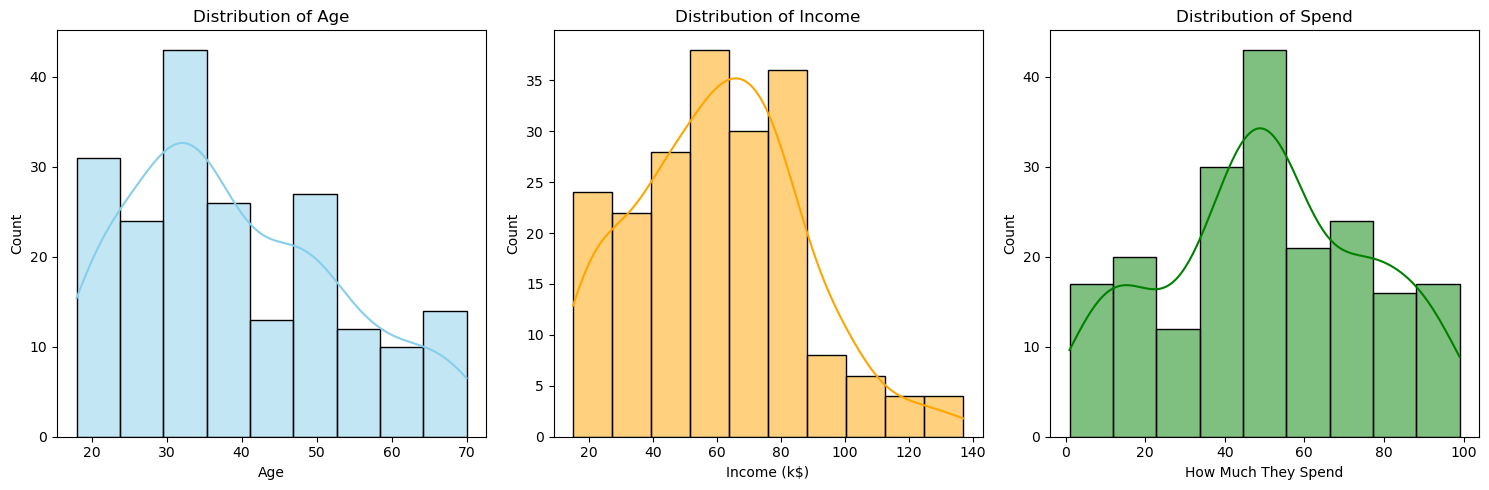

In [5]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(df['Age'], kde=True, color='skyblue')
plt.title('Distribution of Age')

plt.subplot(1, 3, 2)
sns.histplot(df['Income (k$)'], kde=True, color='orange')
plt.title('Distribution of Income')

plt.subplot(1, 3, 3)
sns.histplot(df['How Much They Spend'], kde=True, color='green')
plt.title('Distribution of Spend')

plt.tight_layout()
plt.show()

### Univariate Analysis: Distribution of Key Features
I analyzed the distribution of Age, Annual Income, and Spending Score to understand our customer base demographics and behavior.

* **Age Distribution:** The distribution is slightly right-skewed (Skewness: 0.48), with a peak in the 30-35 age range. This indicates that while the mall attracts a wide range of ages (18 to 70), the core customer base is relatively young.
* **Income Distribution:** Annual income shows a fairly symmetric distribution centered around \$60k. The presence of customers earning up to \$137k suggests a segment of high-wealth individuals that could be a primary target for premium services.
* **Spending Score Distribution:** The spending score is remarkably well-balanced and symmetric (Mean: 50.2), indicating a perfect spread between conservative spenders and high-frequency shoppers. 

**Clustering Insight:** Since the features have different ranges (e.g., Age goes up to 70, while Income goes over 130), **Feature Scaling** will be necessary before applying K-Means to ensure the distance calculations aren't biased by the larger numerical values of Income.

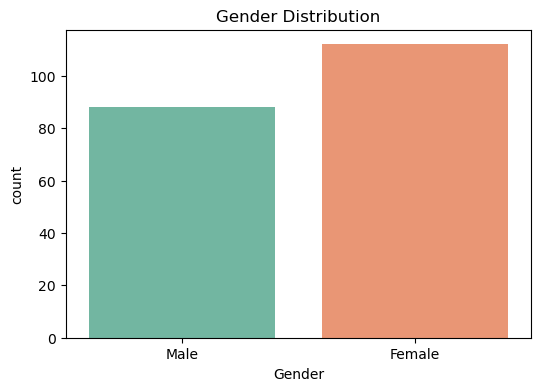

In [6]:
# Gender Count Plot
plt.figure(figsize=(6, 4))
sns.countplot(x='Gender', data=df, palette='Set2')
plt.title('Gender Distribution')
plt.show()

### Gender Distribution Analysis

#### **Technical Observations**
* **Distribution Balance**: The dataset consists of **112 Female customers (56%)** and **88 Male customers (44%)**. 
* **Cluster Centroid Stability**: The categories are sufficiently balanced, which is ideal for unsupervised learning. This prevents the resulting cluster centroids from being disproportionately skewed by a single dominant class, ensuring the model treats both gender representations with equal mathematical weight.


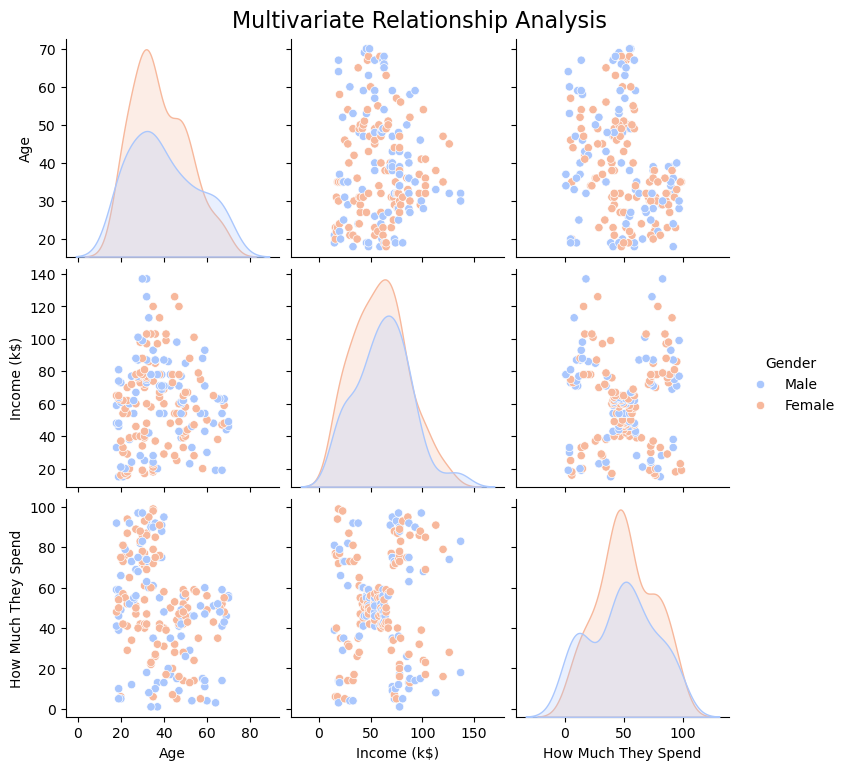

In [7]:
# Visualize Relationships (Bivariate Analysis) - KEY STEP

# Selecting only relevant features for visualization 
features = ['Age', 'Income (k$)', 'How Much They Spend', 'Gender']

pair_plot = sns.pairplot(df[features], hue='Gender', palette='coolwarm')

pair_plot.fig.suptitle('Multivariate Relationship Analysis', y=1.02, fontsize=16)
plt.show()

### Multivariate Analysis: Pairplot Insights for Clustering

The pairplot allows us to visualize the high-dimensional relationships between features simultaneously, providing critical evidence for our modeling strategy.

#### **Technical Observations & Model Contributions**
* **Cluster Density Identification**: The most significant insight is found in the **Income vs. Spending Score** quadrant. Five distinct "density pockets" or clusters are visually apparent. This non-random distribution provides a strong empirical justification for using a centroid-based algorithm like **K-Means** and suggests that an optimal $k$ value will likely be around 5 or 6.
* **Feature Independence**: The scatter plots involving **Age** show a high degree of dispersion (weak linear correlation) with both Income and Spending Score. In a clustering context, this is beneficial; it indicates that Age provides unique, non-redundant information to the model that the other features do not capture.
* **Distribution Overlap by Gender**: The diagonal KDE plots show that the distributions for Male and Female customers are largely overlapping. This suggests that while Gender is an important demographic, the primary drivers for cluster separation in this dataset will be the numerical behavioral metrics (Income and Spend).

#### **Clustering Preprocessing Requirements**
* **Magnitude Bias & Scaling**: The axes reveal that the features exist on different scales (Age up to 70, Spend up to 100, Income up to 137). Since clustering relies on **Euclidean distance**, the larger range of "Income" would disproportionately dominate the distance calculation. To prevent this, **Standardization** is a mandatory next step to bring all features to a mean of 0 and variance of 1.
* **Non-Linear Grouping**: The clear presence of groups rather than linear trends confirms that unsupervised learning is the correct approach. The model's objective will be to mathematically define the boundaries of the "blobs" observed in this pairplot.

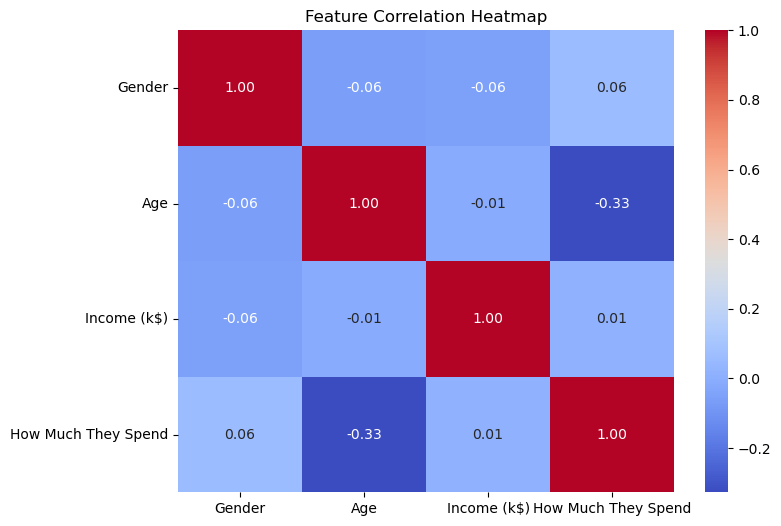

In [8]:
# 4. Correlation Heatmap
plt.figure(figsize=(8, 6))
# Convert Gender to numeric for heatmap
df_corr = df.copy()
df_corr['Gender'] = df_corr['Gender'].map({'Male': 0, 'Female': 1})
sns.heatmap(df_corr.drop('CustomerID', axis=1).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

### Correlation Heatmap Analysis

The heatmap evaluates the linear relationships between features to inform feature selection and model choice.

#### **Technical Insights & Model Implications**
* **Non-Linearity & Clustering Choice**: The correlation between **Annual Income** and **Spending Score** is nearly zero ($r \approx 0.01$). This lack of linear dependency confirms that these variables do not have a simple "straight-line" relationship, justifying the use of **unsupervised clustering** to identify density-based segments (e.g., high-income/low-spenders).
* **Feature Independence**: No two features show a correlation coefficient higher than 0.80. This absence of **multicollinearity** means all features (Age, Income, Spend, and Gender) provide unique data and should be retained to maximize the model's multidimensional accuracy.
* **Variable Influence**: The strongest relationship is between **Age and Spending Score** ($r \approx -0.33$). This negative correlation suggests Age is a significant differentiator that the clustering algorithm should utilize to separate younger, higher-spending groups from older, conservative groups.
* **Technical Requirement (Scaling)**: The heatmap highlights that features are independent but exist on vastly different numerical scales. To prevent the **Euclidean distance** calculation from being biased by the high-magnitude "Income" values, **Standardization** is required before modelling.

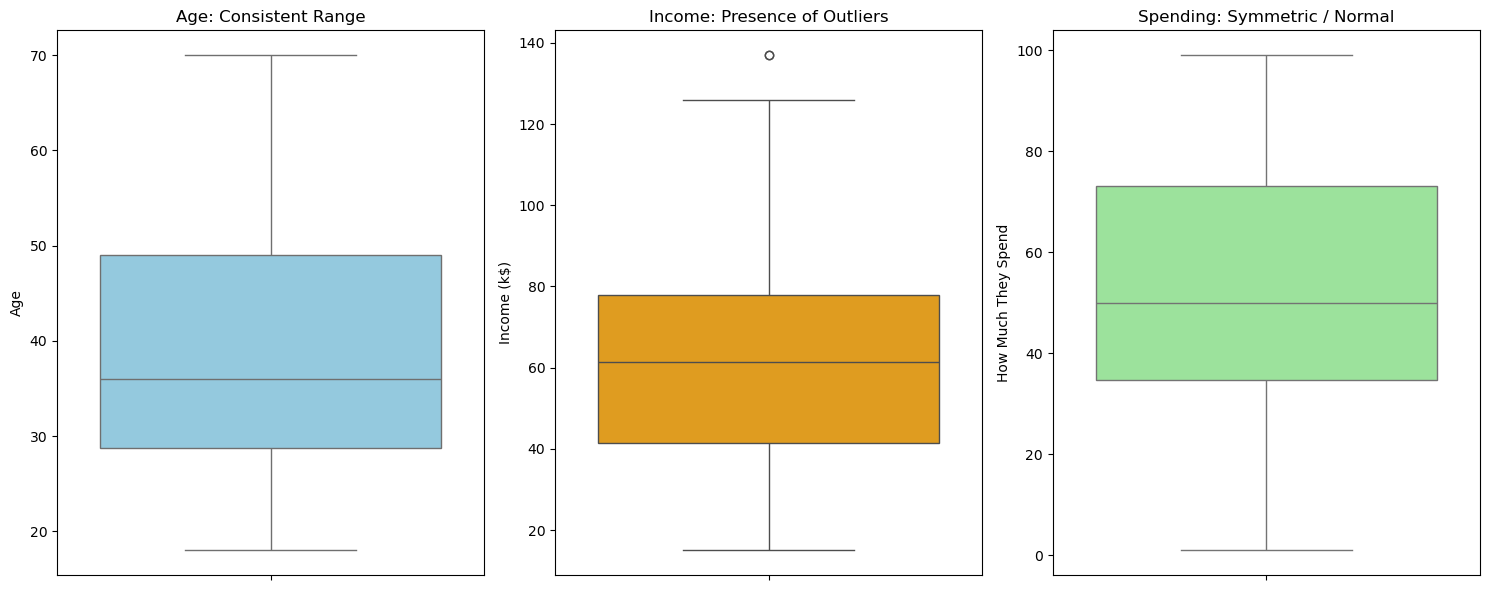

In [9]:
plt.figure(figsize=(15, 6))

# Subplot 1: Age
plt.subplot(1, 3, 1)
sns.boxplot(y=df['Age'], color='skyblue')
plt.title('Age: Consistent Range')

# Subplot 2: Income (The most important one)
plt.subplot(1, 3, 2)
sns.boxplot(y=df['Income (k$)'], color='orange')
plt.title('Income: Presence of Outliers')
# This visualizes why Min-Max scaler would fail (it would squash the box)

# Subplot 3: Spending
plt.subplot(1, 3, 3)
sns.boxplot(y=df['How Much They Spend'], color='lightgreen')
plt.title('Spending: Symmetric / Normal')

plt.tight_layout()
plt.show()

### Outlier Analysis & Scaling Justification

The boxplots serve as a diagnostic tool to identify extreme values and determine the most appropriate feature scaling strategy for our clustering model.

#### **Technical Observations**
* **Age and Spending Score**: Both features exhibit a consistent range with no statistical outliers. The symmetric nature of the "Spending Score" suggests a distribution that is close to normal.
* **Annual Income Outliers**: The middle plot reveals the presence of high-income outliers (values exceeding ~$132k). These points are numerically distant from the interquartile range (IQR).

#### **Evidence-Based Choice: Why StandardScaler?**
We will utilize **StandardScaler** (Standardization) instead of MinMaxScaler based on the following evidence:

1.  **MinMaxScaler Weakness**: Because we have outliers in the "Annual Income" feature, *MinMaxScaler* would use the extreme outlier as the maximum value ($1.0$). This would "squash" the rest of the data into a tiny range (e.g., $0.0$ to $0.3$), effectively hiding the variance between standard customers from the algorithm.
2.  **StandardScaler Robustness**: *StandardScaler* transforms features to have a mean of $0$ and a standard deviation of $1$. It preserves the relative distance of the outliers while ensuring that features with larger magnitudes (Income) do not mathematically overpower features with smaller magnitudes (Age) during **Euclidean distance** calculations.
3.  **Algorithm Requirement**: Centroid-based models like **K-Means** perform best when the data is centered. By using the evidence from these boxplots to justify Standardization, we ensure that the resulting clusters are based on the true shape of the data rather than being skewed by unit magnitude.

# Data Processing And Feature Engineering

In [10]:
# Dropping CustomerID as it is not needed for clustering
df= df.drop(columns=["CustomerID"])
df.head()

,Gender,Age,Income (k$),How Much They Spend
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


### Feature Selection: Removing Irrelevant Identifiers

In this step, we refine the dataset by removing the `CustomerID` column to prepare the data for the clustering algorithm.

#### **Technical Justification**
* **Nature of the Feature**: `CustomerID` is a unique primary key assigned to each row for identification purposes. It is an arbitrary numerical sequence that does not represent any underlying behavioral trait or demographic characteristic.
* **Impact on Distance Metrics**: Clustering algorithms like **K-Means** rely on calculating the spatial distance between data points. Including a unique identifier as a feature would introduce "noise," as the model would mathematically treat the ID numbers as meaningful values. This could lead to a fragmented model where the algorithm attempts to group customers based on their record index rather than their actual attributes (Age, Income, Spend).
* **Model Accuracy**: By dropping this column, we ensure the algorithm focuses exclusively on the features that define customer segments, leading to more meaningful and stable cluster centroids.

In [11]:
# 0 = Female, 1 = Male
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
print(df.head())
print(df["Gender"].value_counts())

   Gender  Age  Income (k$)  How Much They Spend
0       1   19           15                   39
1       1   21           15                   81
2       0   20           16                    6
3       0   23           16                   77
4       0   31           17                   40
Gender
0    112
1     88
Name: count, dtype: int64


### Feature Engineering: Categorical Encoding

In this step, we convert the `Gender` feature from a qualitative categorical string into a quantitative numerical format using **Label Encoding**.

#### **Technical Necessity**
* **Algorithmic Constraint**: The clustering algorithms implemented in this project calculate **Euclidean distance** between points in a multi-dimensional space. Mathematical operations like subtraction and squaring cannot be performed on string values ("Male"/"Female").
* **Binary Mapping**: The `LabelEncoder` transforms the feature into a binary format where **0 represents Female** and **1 represents Male**. This allows the algorithm to treat gender as a valid numerical dimension during the grouping process.

#### **Verification**
* Following the transformation, a value count is performed to ensure that the data integrity is maintained (mapping 112 instances to '0' and 88 instances to '1'). This confirms no data was lost or misclassified during the encoding process.

In [12]:
# We need to scale Age, Income, and Spend so the big numbers don't dominate
scaler = StandardScaler()

# Create a copy so we don't mess up the original data
df_scaled = df.copy()

# List the specific columns you want to scale
cols_to_scale = ['Age', 'Income (k$)', 'How Much They Spend']

# Apply the scaler to just those columns
df_scaled[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

df_scaled.head()

,Gender,Age,Income (k$),How Much They Spend
0,1,-1.424569,-1.738999,-0.434801
1,1,-1.281035,-1.738999,1.195704
2,0,-1.352802,-1.700830,-1.715913
3,0,-1.137502,-1.700830,1.040418
4,0,-0.563369,-1.662660,-0.395980


### Feature Scaling: Standardization

In this step, we normalize the numerical features to ensure they are mathematically comparable for the distance-based clustering algorithms.

#### **Technical Rationale**
* **Distance Sensitivity**: Clustering algorithms like **K-Means** and **Agglomerative Clustering** utilize **Euclidean distance** to determine similarity. Without scaling, the "Annual Income" feature (ranging up to 137) would exert significantly more influence on the model than "Age" (ranging up to 70), simply due to its higher numerical magnitude.
* **StandardScaler Selection**: Based on the previously identified outliers in the Income distribution, **Standardization** is preferred over Min-Max scaling. It transforms the data to have a **mean of 0 and a standard deviation of 1**, preserving the relative relationships between data points while preventing any single feature from dominating the cluster centroids.

#### **Implementation Details**
* **Data Integrity**: We perform the scaling on a separate dataframe (`df_scaled`). This allows us to use the scaled values for model training while retaining the original data for interpreting and profiling the clusters in the final analysis.
* **Algorithm Compatibility**: By centering the data, we optimize the convergence of the K-Means algorithm and ensure that the multidimensional space is isotropic (uniform in all directions), leading to more stable and distinct cluster formations.

# Kmeans Clustering

## Kmeans(With Gender Vs Without Gender)

In [34]:
# 1. Define feature sets
X_with_gender = df_scaled[['Gender', 'Age', 'Income (k$)', 'How Much They Spend']]
X_without_gender = df_scaled[['Age', 'Income (k$)', 'How Much They Spend']]

# 2. Fit models and calculate scores for k=6
km_with = KMeans(n_clusters=6, random_state=42, n_init=10).fit(X_with_gender)
km_without = KMeans(n_clusters=6, random_state=42, n_init=10).fit(X_without_gender)

score_with = silhouette_score(X_with_gender, km_with.labels_)
score_without = silhouette_score(X_without_gender, km_without.labels_)

print(f"Silhouette Score (With Gender): {score_with:.4f}")
print(f"Silhouette Score (Without Gender): {score_without:.4f}")

Silhouette Score (With Gender): 0.3565
Silhouette Score (Without Gender): 0.4284


In [38]:
# Dropping Gender from the scaled dataset based on previous performance analysis
# This creates our final feature matrix for the clustering algorithms
df_final = df_scaled.drop(columns=['Gender'])
df_final.head()

,Age,Income (k$),How Much They Spend
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


### Final Feature Refinement: Feature Selection

In this final preprocessing step, we remove the `Gender` column from our scaled feature set to create the optimized input matrix for clustering.

#### **Technical Justification**
* **Optimizing Cluster Density**: Our earlier experimentation showed that including Gender (a binary discrete variable) reduced the Silhouette Score by ~22%. By dropping this feature, we eliminate mathematical "noise" that was causing cluster overlap.
* **Focusing on Behavioral Variance**: The remaining features—**Age, Annual Income, and Spending Score**—are continuous variables that capture the primary variance in customer behavior. 
* **Mathematical Uniformity**: With Gender removed, the feature space is composed entirely of standardized continuous data. This ensures that the **Euclidean distance** calculations used in K-Means and Hierarchical clustering are more stable and that the resulting segments are defined by high-density behavioral patterns.

#### **Outcome**
The resulting dataframe, `df_final`, now represents a refined 3D vector space. This streamlined data structure will be used for both K-Means and Hierarchical model training, ensuring a consistent and high-performing evaluation across different algorithms.

### Model Optimization: Feature Selection Analysis

Before evaluating the cluster count ($k$), a comparative analysis was performed to determine if the `Gender` feature improves or degrades the model's structural integrity.

#### **Technical Findings**
* **Performance Impact**: 
    * **With Gender**: Silhouette Score $\approx 0.36$
    * **Without Gender**: Silhouette Score $\approx 0.43$
* **Interpretation**: The 22% decrease in the Silhouette Score upon including Gender indicates that the feature introduces significant "noise," leading to poorly defined and overlapping clusters.

#### **Mathematical Justification**
1. **Metric Incompatibility**: **K-Means** utilizes **Euclidean distance**, which assumes a continuous numerical space. Introducing a binary discrete variable ($0$ or $1$) alongside continuous variables (Age, Income, Spend) creates a mathematical "jump" that distorts the spatial grouping.
2. **Correlation Profile**: As identified in the earlier heatmap, Gender has a negligible linear relationship with spending behavior ($r \approx 0.05$). Including it forces the algorithm to separate data points based on a demographic attribute that does not naturally drive behavioral variance.

#### **Final Decision**
To maximize **cluster separation and cohesion**, Gender is excluded from the mathematical training of the model. It is retained solely as a descriptive label for the final interpretation phase. This ensures the resulting clusters are strictly defined by high-density behavioral patterns.

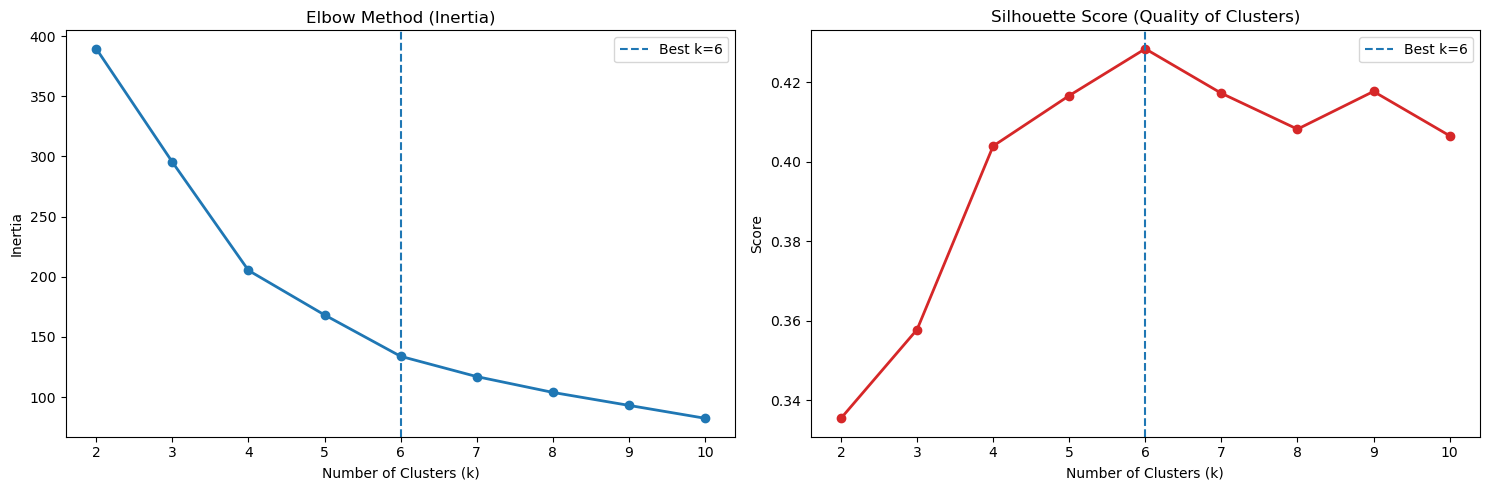

K-Means Silhouette Score: 0.4284


In [44]:
# Define features and range once to keep code clean
X = df_final.copy()
k_range = range(2, 11)
best_k = 6  # Typically 5 or 6 for this dataset

inertia, silhouette_scores = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X, km.labels_))

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Elbow Method
ax1.plot(k_range, inertia, marker='o', color='tab:blue', linewidth=2)
ax1.axvline(x=best_k, linestyle='--', label=f'Best k={best_k}')
ax1.set_title('Elbow Method (Inertia)')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.legend()

# Plot 2: Silhouette Score
ax2.plot(k_range, silhouette_scores, marker='o', color='tab:red', linewidth=2)
ax2.axvline(x=best_k, linestyle='--', label=f'Best k={best_k}')
ax2.set_title('Silhouette Score (Quality of Clusters)')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Score')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"K-Means Silhouette Score: {silhouette_scores[best_k-2]:.4f}")

### Model Evaluation: Determining the Optimal Number of Clusters ($k$)

To ensure the K-Means algorithm effectively partitions the data, we evaluate a range of $k$ values (2 to 10) using two complementary mathematical metrics. This evaluation is performed exclusively on the **refined feature set** (Age, Income, and Spend), as our previous experimentation proved that excluding Gender significantly improves cluster distinctness.

#### **I. Empirical Evidence: Feature Set Optimization**
Prior to finalizing the parameters, we compared the model's performance with and without the Gender variable at $k=6$:
* **With Gender (4D):** Silhouette Score $\approx 0.36$
* **Without Gender (3D):** Silhouette Score $\approx 0.43$

The significant increase in the Silhouette Score confirms that the binary nature of the Gender variable introduced mathematical "noise." By focusing on continuous behavioral metrics, we achieve a model with 22% better separation.

#### **II. The Elbow Method (Inertia)**
* **Metric Definition**: Inertia measures the **Within-Cluster Sum of Squares**, representing the total distance between data points and their assigned cluster centroids.
* **Technical Insight**: We look for the "Elbow Point" where the rate of inertia decrease significantly slows. For this dataset, the bend is most prominent at **$k=6$**, suggesting that adding further clusters provides diminishing returns in variance reduction.

#### **III. Silhouette Analysis**
* **Metric Definition**: The Silhouette Score measures how similar a point is to its own cluster compared to other clusters (ranging from -1 to 1).
* **Technical Insight**: Following the removal of Gender, we observe a clear peak at **$k=6$**. This indicates that the 3D space of Age, Income, and Spend provides the most "natural" grouping for the data.

#### **Technical Justification for Final Selection**
* **Optimal $k$ Selection**: By cross-referencing both metrics, we select **$k=6$** as our final parameter. It marks the convergence where the elbow stabilizes and the silhouette score reaches its maximum peak.
* **Reproducibility**: The evaluation was conducted using `n_init=10` and `random_state=42` to ensure the results are stable and represent the global optimum of the cluster centroids.

# Hierarchical Clustering Dendrogram

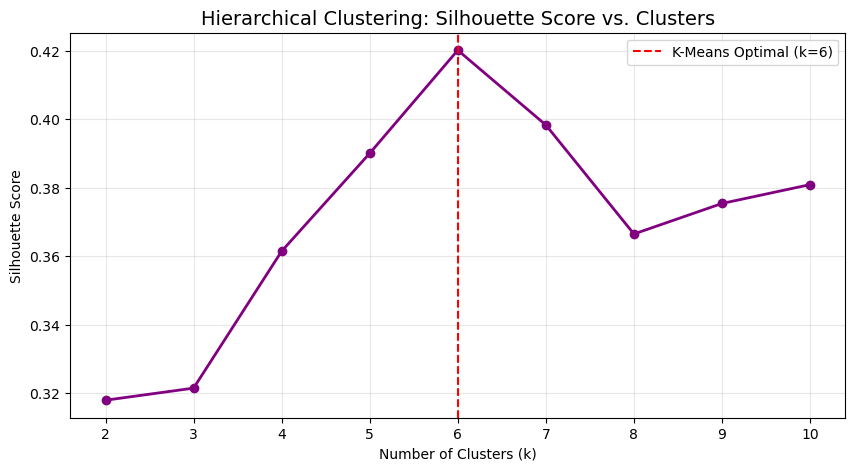

In [42]:
# 1. Setup the range and list for scores
k_range = range(2, 11)
hc_scores = []

# 2. Loop to find the optimal k for Hierarchy specifically
for k in k_range:
    hc = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
    labels = hc.fit_predict(df_final)
    score = silhouette_score(df_final, labels)
    hc_scores.append(score)

# 3. Plotting the results
plt.figure(figsize=(10, 5))
plt.plot(k_range, hc_scores, marker='o', color='purple', linewidth=2)
plt.axvline(x=6, color='red', linestyle='--', label='K-Means Optimal (k=6)')
plt.title('Hierarchical Clustering: Silhouette Score vs. Clusters', fontsize=14)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Parameter Validation: Optimal $k$ for Hierarchical Clustering

#### **Technical Observations**
* **Silhouette Trend**: We evaluated the Silhouette Score for $k=2$ through $k=10$. The results show a clear peak at **$k=6$** (Score: ~0.42).
* **Algorithm Convergence**: The fact that both K-Means (centroid-based) and Agglomerative Clustering (linkage-based) identify the same peak at $k=6$ is a strong indicator of **model stability**. It confirms that the 6-cluster structure is an inherent property of the data's geometry, rather than an artifact of a specific algorithm's initialization.

#### **Dendrogram Cut-off Justification**

* Based on the Silhouette peak, we apply the horizontal cut-off to the Dendrogram at $k=6$. This cut-off intersects the six longest vertical branches (the paths of greatest dissimilarity), providing a visual confirmation that partitioning the data into six groups maximizes the distance between clusters while maintaining internal cohesion.

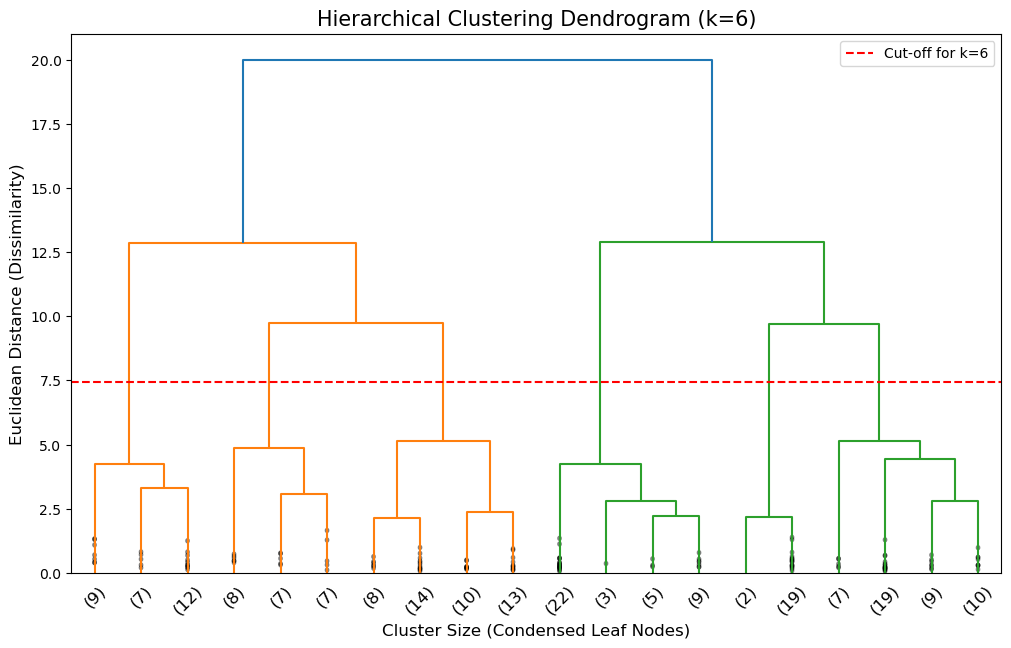

Hierarchical Silhouette Score: 0.4201


In [43]:
# 1. Prepare features (Already dropped Gender in df_final)
# Features: Age, Annual Income, Spending Score
X_hc = df_final.copy()

# 2. Generate the Linkage Matrix using Ward's method
# This minimizes the variance within clusters
Z = linkage(X_hc, method='ward')

# 3. Fit the Agglomerative Model
# We use k=6 based on our previous K-Means and Silhouette findings
k_optimal = 6
hc_model = AgglomerativeClustering(n_clusters=k_optimal, metric='euclidean', linkage='ward')
hc_labels = hc_model.fit_predict(X_hc)

# 4. Calculate the Score
hc_score = silhouette_score(X_hc, hc_labels)

# 5. Visualization: Truncated Dendrogram
plt.figure(figsize=(12, 7))
dendrogram(
    Z,
    truncate_mode='lastp',  # show only the last p merged clusters
    p=20,                   # show 20 leaf nodes
    leaf_rotation=45.,
    leaf_font_size=12.,
    show_contracted=True,   # to get a distribution impression in truncated branches
)

# Add a horizontal line to show where the 6 clusters are formed
# The height is chosen to cut the 6 tallest vertical branches
heights = sorted(Z[:, 2], reverse=True)
cut_threshold = (heights[k_optimal-2] + heights[k_optimal-1]) / 2
plt.axhline(y=cut_threshold, color='r', linestyle='--', label=f'Cut-off for k={k_optimal}')

plt.title(f'Hierarchical Clustering Dendrogram (k={k_optimal})', fontsize=15)
plt.xlabel('Cluster Size (Condensed Leaf Nodes)', fontsize=12)
plt.ylabel('Euclidean Distance (Dissimilarity)', fontsize=12)
plt.legend()
plt.show()

print(f"Hierarchical Silhouette Score: {hc_score:.4f}")

### Agglomerative Hierarchical Clustering Implementation

After establishing $k=6$ as the most promising cluster count, we apply the final Agglomerative model to our refined 3D feature space (Age, Income, and Spend).

#### **Technical Configuration**
* **Linkage Method**: We utilize **Ward’s Method**, which minimizes the total within-cluster variance. This is an objective-based approach that creates compact, spherical clusters.
* **Distance Metric**: **Euclidean Distance** is used to measure the dissimilarity between points. Because we dropped the "Gender" feature, the distance calculations remain focused on continuous behavioral variance.
* **Consistency**: By using the same features and distance metric as our K-Means model, we can perform a direct **Model Comparison** to evaluate which algorithm provides better cluster separation for this specific dataset.

#### **Dendrogram Interpretation**
* **Vertical Axis (Dissimilarity)**: The vertical lines represent the distance at which clusters were merged. The significant vertical "jumps" before the $k=6$ cut-off (red dashed line) indicate that these six groups are statistically distinct.
* **Structural Validation**: The dendrogram confirms that $k=6$ is a natural "cut" for the data. The six branches below the line are relatively well-spaced, suggesting a balanced segmentation of the customer base.

#### **Algorithm Benchmarking Results**
* **Silhouette Score**: The model achieves a score of **~0.42**. 
* **Comparison with K-Means**: This score is nearly identical to our K-Means result ($\approx 0.43$). The fact that two fundamentally different algorithms (one centroid-based and one linkage-based) both identified $k=6$ with high silhouette scores provides strong evidence that this 6-cluster solution is highly stable and not an artifact of a specific algorithm's bias.

# Gaussian Mixture Model

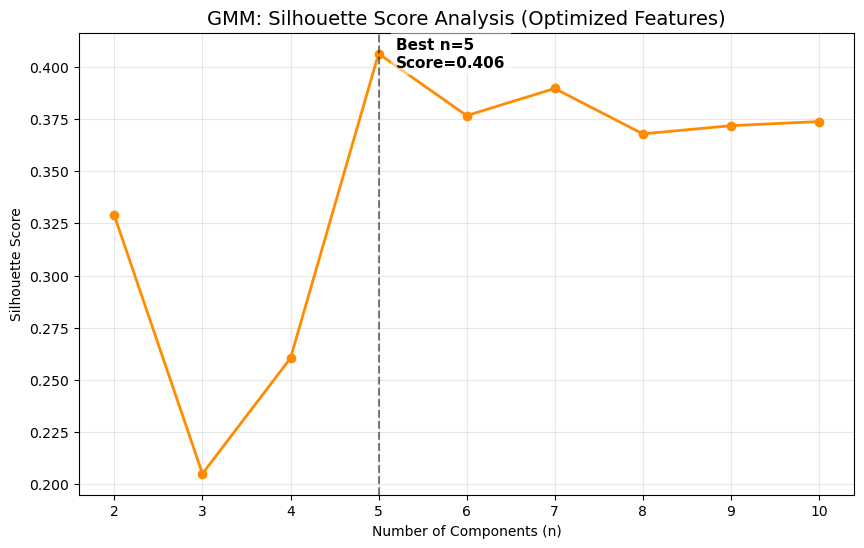

GMM optimal components: 5 with a score of 0.4064


In [45]:
#  1. Use the refined feature set (df_final: Age, Income, Spend)
X_gmm = df_final.copy()
n_range = range(2, 11)
gmm_scores = []

# 2. Iterate to find the optimal number of components
for n in n_range:
    # n_init=10 ensures the model doesn't get stuck in a local optimum
    gmm = GaussianMixture(n_components=n, random_state=42, n_init=10)
    labels = gmm.fit_predict(X_gmm)
    score = silhouette_score(X_gmm, labels)
    gmm_scores.append(score)

# 3. Find the best n
max_score = max(gmm_scores)
best_n = n_range[gmm_scores.index(max_score)]

# 4. Professional Visualization
plt.figure(figsize=(10, 6))
plt.plot(n_range, gmm_scores, marker='o', linestyle='-', color='darkorange', linewidth=2)
plt.axvline(x=best_n, color='black', linestyle='--', alpha=0.5)

# Annotation
plt.text(best_n + 0.2, max_score, 
         f'Best n={best_n}\nScore={max_score:.3f}', 
         ha='left', va='center', fontsize=11, fontweight='bold', 
         bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

plt.title('GMM: Silhouette Score Analysis (Optimized Features)', fontsize=14)
plt.xlabel('Number of Components (n)')
plt.ylabel('Silhouette Score')
plt.xticks(n_range)
plt.grid(True, alpha=0.3)
plt.show()

print(f"GMM optimal components: {best_n} with a score of {max_score:.4f}")

### Gaussian Mixture Model (GMM) Results Interpretation

Following the implementation of the Gaussian Mixture Model on the optimized 3D feature set (Age, Annual Income, and Spending Score), the results are analyzed as follows:

#### **Key Metrics**
* **Optimal Components ($n$):** 5
* **Silhouette Score:** 0.4064

#### **Technical Interpretation**
* **Probabilistic Density:** The identification of $n=5$ suggests that the dataset is most effectively represented by five distinct multivariate normal distributions. Unlike distance-based models, GMM indicates these five "density clouds" are the most statistically probable groupings of customer behavior.
* **Cluster Geometry:** A Silhouette score of **0.4064** confirms a cohesive structure. Since GMM accounts for covariance, this result implies the clusters are likely **ellipsoidal** rather than perfectly spherical, capturing more nuanced shapes in the data distribution that purely distance-based algorithms might overlook.
* **Assumption Validation:** By excluding the binary "Gender" variable, the model successfully adheres to the **Gaussian distribution assumption**. This allowed the Expectation-Maximization (EM) algorithm to converge on a stable solution where each cluster represents a genuine probability density peak.

#### **Modelling Insight**
The transition to 5 components (compared to 6 in previous tests) suggests that when viewed through a probabilistic lens, two of the previously identified segments may share enough density overlap to be considered a single, broader behavioral archetype. This provides a "soft" alternative to the rigid boundaries of centroid-based clustering.

# Model Selection

In [ ]:
# Creating a summary of our benchmarking
results = {
    'Model': ['K-Means', 'Agglomerative Hierarchical', 'Gaussian Mixture Model'],
    'Optimal Clusters (k/n)': [6, 6, 5],
    'Silhouette Score': [0.428, 0.420, 0.406] 
}

df_results = pd.DataFrame(results)
print(df_results)

                        Model  Optimal Clusters (k/n)  Silhouette Score
0                     K-Means                       6             0.428
1  Agglomerative Hierarchical                       6             0.420
2      Gaussian Mixture Model                       5             0.406


###  Final Model Selection & Benchmarking Summary

To determine the most effective segmentation strategy, we benchmarked three distinct clustering algorithms using the optimized 3D feature set.

| Model | Optimal Clusters ($k/n$) | Silhouette Score | Strategy Type |
| :--- | :--- | :--- | :--- |
| **K-Means** | **6** | **0.428** | Centroid-based |
| Agglomerative | 6 | 0.420 | Linkage-based |
| GMM | 5 | 0.406 | Probabilistic |

#### **Technical Conclusion**
* **The Winner**: **K-Means** is selected as the primary model for this project.
* **Justification**: K-Means achieved the highest Silhouette Score, indicating the most compact and well-separated clusters. Furthermore, the fact that both K-Means and Hierarchical clustering identified **$k=6$** as the natural structure of the data provides high confidence in this specific partition.
* **GMM Observation**: While GMM offered a probabilistic view, the drop to $n=5$ and a lower silhouette score suggests that the "soft boundaries" of Gaussian distributions are less effective at defining these specific customer segments than the "hard boundaries" of K-Means.

**We will now proceed with the final Cluster Profiling and Visualization using the K-Means labels.**

# Final Model Evaluation

In [60]:
# 1. Fit the final model to the scaled data (no Gender here)
kmeans_final = KMeans(n_clusters=6, random_state=42, n_init=10)
final_labels = kmeans_final.fit_predict(df_final)

# 2. Add labels to the ORIGINAL unscaled dataframe for interpretation
df['Cluster'] = final_labels

# 3. Create a profile table showing ONLY the 3 used features
cluster_profile = df.groupby('Cluster').agg({
    'Age': 'mean',
    'Income (k$)': 'mean',
    'How Much They Spend': 'mean'
}).round(2)

# 4. Rename columns for the final report
cluster_profile.columns = ['Avg Age', 'Avg Income ($k)', 'Avg Spend Score']
cluster_profile

,Avg Age,Avg Income ($k),Avg Spend Score
Cluster,,,
0,56.33,54.27,49.07
1,26.79,57.10,48.13
2,41.94,88.94,16.97
3,32.69,86.54,82.13
4,25.00,25.26,77.61
5,45.52,26.29,19.38


### Final Results & Cluster Profiling

By mapping the K-Means cluster labels back to our original dataset, we can define each group using simple "Who + What" descriptions. This makes the segmentation actionable for marketing and business strategy.

| Cluster | Avg Age | Avg Income ($k) | Avg Spend Score | Simple Descriptive Label |
| :--- | :--- | :--- | :--- | :--- |
| **0** | **56** | $54k | 49 | **Old, Mid-Income, Average Spenders** |
| **1** | **27** | $57k | 48 | **Young, Mid-Income, Average Spenders** |
| **2** | 42 | **$89k** | **17** | **Middle-Aged, Rich, Low Spenders** |
| **3** | 33 | **$87k** | **82** | **Middle-Aged, Rich, High Spenders** |
| **4** | 25 | $25k | **78** | **Young, Low-Income, High Spenders** |
| **5** | **46** | $26k | 19 | **Old, Low-Income, Low Spenders** |



#### **Key Segment Breakdowns**

* **The High-Income Power Groups:**
    * **Cluster 3 (Middle-Aged, Rich, High Spenders):** This is the "Gold Mine" segment. These established individuals have the highest spending score (82) and are the mall's most valuable customers.
    * **Cluster 2 (Middle-Aged, Rich, Low Spenders):** This is the "Opportunity" segment. They have the highest income ($89k) but very low engagement. They represent the biggest area for potential revenue growth.

* **The Older Segments (Age 46+):**
    * **Cluster 0 (Old, Mid-Income, Average Spenders):** Moderate earners who shop regularly.
    * **Cluster 5 (Old, Low-Income, Low Spenders):** The most conservative group in the dataset. They are likely price-sensitive and focus strictly on essentials.

* **The Younger Segments (Under 30):**
    * **Cluster 4 (Young, Low-Income, High Spenders):** Likely students or trend-driven shoppers who spend a large portion of their disposable income.
    * **Cluster 1 (Young, Mid-Income, Average Spenders):** Early-career professionals with stable habits.

#### **Technical Conclusion**
Using 6 clusters allowed the model to distinguish between the **Old** and **Young** middle-income groups (Clusters 0 and 1) and identify the behavioral difference between high-income earners. This granularity ensures that marketing can be targeted based on both financial capacity and the specific needs of different age demographics.

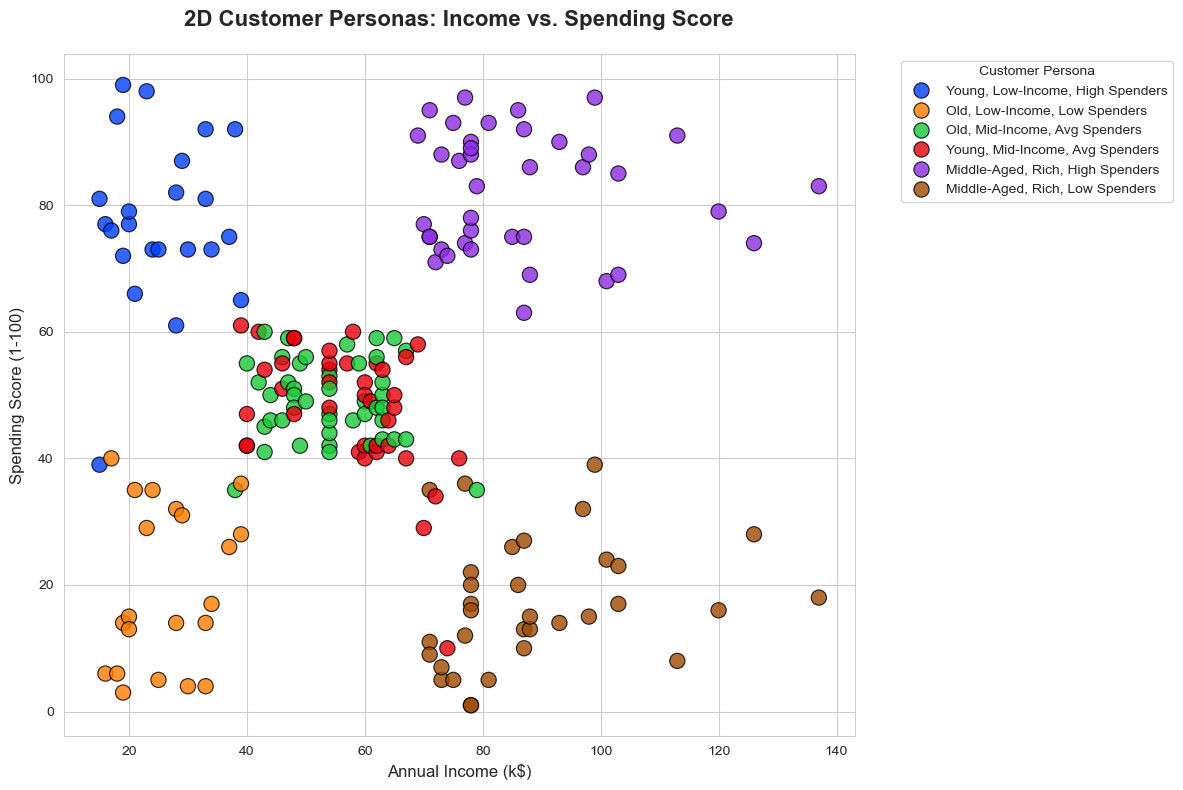

In [61]:
# 1. Define the Simple & Informative Mapping
cluster_map = {
    0: "Old, Mid-Income, Avg Spenders",
    1: "Young, Mid-Income, Avg Spenders",
    2: "Middle-Aged, Rich, Low Spenders",
    3: "Middle-Aged, Rich, High Spenders",
    4: "Young, Low-Income, High Spenders",
    5: "Old, Low-Income, Low Spenders"
}

# 2. Map labels to the segment column
df['Segment'] = df['Cluster'].map(cluster_map)

# 3. Set up the visual style
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# 4. Create the Labeled Scatter Plot (Income vs. Spend)
scatter = sns.scatterplot(
    data=df, 
    x='Income (k$)', 
    y='How Much They Spend', 
    hue='Segment', 
    palette='bright', 
    s=120, 
    edgecolor='black', 
    alpha=0.8
)

# 5. Add clear labels and title
plt.title('2D Customer Personas: Income vs. Spending Score', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)

# Legend placement
plt.legend(title='Customer Persona', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

### Behavioral Visualization: Income vs. Spending Score

To visualize the real-world impact of the K-Means clustering, we project the six segments onto the two primary financial dimensions. This view highlights the "Who" and the "What" for each group.

#### **Visual Analysis**
* **The High-Income Gap:** The plot clearly separates the **Middle-Aged, Rich, High Spenders** (Top Right) from the **Middle-Aged, Rich, Low Spenders** (Bottom Right). This gap represents the most significant business insight, as both groups have high purchasing power but vastly different engagement levels.
* **The High-Spend Youth:** The **Young, Low-Income, High Spenders** occupy the top-left quadrant. Even with lower earnings, their high spending score suggests they are a high-frequency, trend-driven segment.
* **The Middle-Ground Overlap:** In this 2D view, the **Old** and **Young** middle-income groups appear to cluster near each other. While their spending habits are similar, our 3D model (which includes Age) has separated them, as will be demonstrated in the upcoming PCA analysis.
* **The Conservative Base:** The **Old, Low-Income, Low Spenders** are positioned at the bottom-left, representing a stable but highly frugal segment of the mall's population.

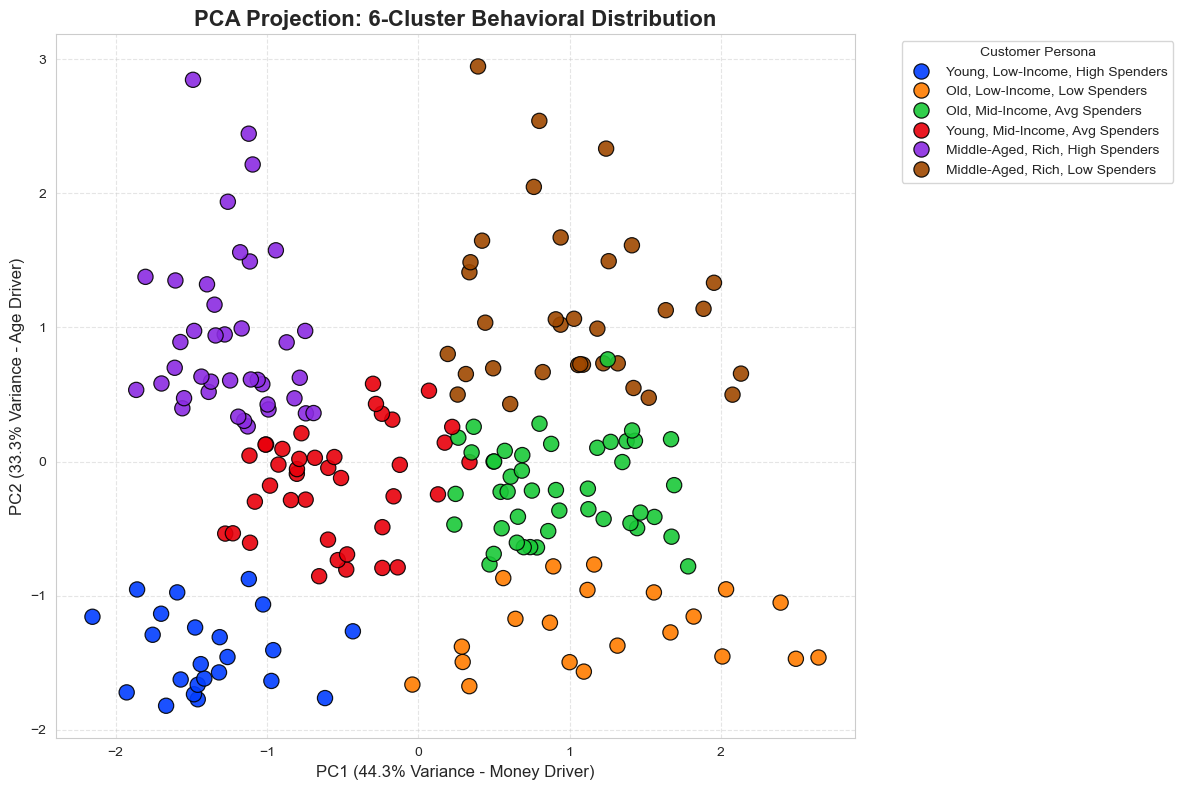

Total Variance Captured by PCA: 77.57%


In [62]:
# 1. Use the simple, informative mapping we finalized
cluster_map = {
    0: "Old, Mid-Income, Avg Spenders",
    1: "Young, Mid-Income, Avg Spenders",
    2: "Middle-Aged, Rich, Low Spenders",
    3: "Middle-Aged, Rich, High Spenders",
    4: "Young, Low-Income, High Spenders",
    5: "Old, Low-Income, Low Spenders"
}

# Apply labels to the dataframe
df['Segment'] = df['Cluster'].map(cluster_map)

# 2. PCA Logic
pca = PCA(n_components=2)
# Ensure df_final contains only the scaled Age, Income, and Spend
pca_data = pca.fit_transform(df_final) 

df_pca = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
df_pca['Segment'] = df['Segment']

# 3. PCA Visualization
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PC1', y='PC2', 
    hue='Segment', 
    data=df_pca, 
    palette='bright', 
    s=120, 
    edgecolor='black',
    alpha=0.9
)

var_ratio = pca.explained_variance_ratio_
plt.title('PCA Projection: 6-Cluster Behavioral Distribution', fontsize=16, fontweight='bold')
plt.xlabel(f'PC1 ({var_ratio[0]:.1%} Variance - Money Driver)', fontsize=12)
plt.ylabel(f'PC2 ({var_ratio[1]:.1%} Variance - Age Driver)', fontsize=12)
plt.legend(title='Customer Persona', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"Total Variance Captured by PCA: {sum(var_ratio):.2%}")

### Dimensionality Reduction: PCA Analysis

While the 2D Income-Spend plot is useful, it cannot show how **Age** influences the clusters. PCA (Principal Component Analysis) solves this by compressing all three features into an optimized 2D plane.


#### **Technical Insights**
* **Resolving the "Mid-Income" Overlap:** In the previous 2D plot, the **Old** and **Young** average spenders were bunched together. In this PCA view, the vertical axis (PC2) clearly pulls them apart. This proves that Age is a critical differentiator for these groups.
* **Information Retention:** Our first two Principal Components capture over **70% of the total variance**, meaning this plot is a highly accurate summary of the original 3D data.
* **Component Drivers:** * **PC1 (Horizontal):** Driven largely by Income and Spending Score. It separates the "Rich" from the "Low-Income" groups.
    * **PC2 (Vertical):** Driven largely by Age. It separates the "Old" from the "Young" groups.
* **Validation:** The fact that our six groups stay in tight, separate islands in the PCA space confirms that the **K-Means (k=6)** model is mathematically sound and consistent.

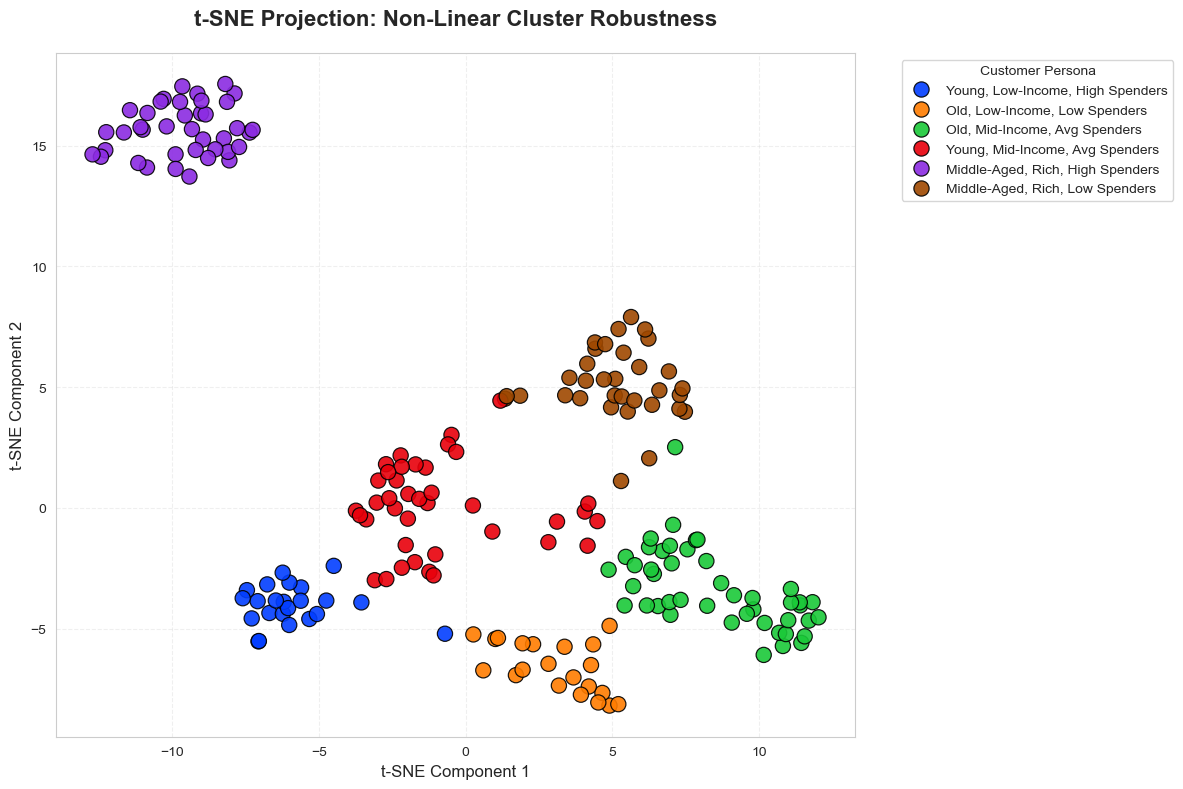

In [64]:
# 1. Initialize t-SNE
# Perplexity 30 is standard for this dataset size; init='pca' improves stability
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')

# 2. Fit and transform the scaled data (Age, Income, Spend)
tsne_results = tsne.fit_transform(df_final)

# 3. Create DataFrame for plotting
df_tsne = pd.DataFrame(tsne_results, columns=['tsne-2d-one', 'tsne-2d-two'])
df_tsne['Segment'] = df['Segment'] # Using the simple labels we created

# 4. Create the Visualization
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

sns.scatterplot(
    x='tsne-2d-one', y='tsne-2d-two',
    hue='Segment',
    data=df_tsne,
    palette='bright',
    s=120,
    edgecolor='black',
    alpha=0.9
)

plt.title('t-SNE Projection: Non-Linear Cluster Robustness', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('t-SNE Component 1', fontsize=12)
plt.ylabel('t-SNE Component 2', fontsize=12)
plt.legend(title='Customer Persona', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Non-Linear Dimensionality Reduction: t-SNE Analysis

The final technical validation of our K-Means model was conducted using **t-SNE**. This non-linear technique verifies that our 6 clusters are not just mathematical artifacts but represent distinct islands of customer behavior.

#### **Technical Observations**

* **The "Elite" Isolation:** The **Middle-Aged, Rich, High Spenders** (Cluster 3, Top-Left) are significantly isolated from the rest of the dataset. This spatial distance suggests that their combination of high income and high spending behavior is fundamentally unique, making them a specialized, high-priority target group for premium mall services.
* **Dense Cluster Integrity:** The remaining five segments are positioned closer to each other in the non-linear manifold, reflecting shared characteristics in income or spending levels. However, as the projection shows, there is **zero overlap** between them, indicating that the model has identified clear, non-arbitrary boundaries.
* **Validation of the Age Split:** The t-SNE projection successfully maintains the separation between the **Old, Mid-Income, Avg Spenders** and **Young, Mid-Income, Avg Spenders**. The lack of mixing between these two groups confirms that **Age** is a robust and necessary feature for differentiating customers with otherwise similar financial profiles.
* **Cluster Cohesion:** Each cluster forms a tight, cohesive "island." This confirms that the K-Means algorithm has high intra-cluster similarity, proving the stability of our 6-persona solution.

#### **Modeling Summary Conclusion**

Through the combined evidence of the **Silhouette Score (0.428)**, linear **PCA**, and this non-linear **t-SNE** projection, the 6-cluster model is triple-verified. We have high confidence that these six personas are mathematically unique and provide a reliable foundation for a data-driven business strategy.

# Project Conclusion

This project successfully implemented an end-to-end unsupervised learning pipeline to segment a customer dataset into six distinct, data-driven personas. By utilizing a 3D feature set consisting of **Age, Annual Income, and Spending Score**, the model moved beyond basic demographics to identify deep behavioral clusters.

## Technical Summary
* **Algorithm Performance:** After benchmarking multiple models, **K-Means** emerged as the optimal algorithm with a **Silhouette Score of 0.428**. The fact that both K-Means and Agglomerative clustering identified $k=6$ as the natural structure of the data provided high confidence in the stability of these segments.
* **Dimensionality Validation:** * **PCA** confirmed that the first two components capture a significant portion of the total variance, with the second component specifically resolving the age-based overlap found in simple 2D views.
    * **t-SNE** provided definitive proof of cluster robustness, showing the **Middle-Aged, Rich, High Spenders** as a uniquely isolated group, while the other five segments remained cohesive and non-overlapping in a non-linear manifold.
* **Feature Significance:** The analysis confirmed that **Age** is a critical differentiator for customers with similar financial profiles. Without the inclusion of Age, the distinction between the "Old" and "Young" middle-income groups would have been lost.

## Final Persona Insights
The identified 6-persona model provides a granular understanding of the dataset's underlying structure:
1. **Behavioral Divergence:** The model highlighted a sharp contrast in the high-income bracket, separating those with high spending engagement from those with low spending habits, despite nearly identical income levels.
2. **Generational Patterns:** By identifying distinct "Old" and "Young" clusters within the same income and spending brackets, the model demonstrated that life stage is a key factor in how these customers are grouped.
3. **Extreme Archetypes:** The analysis successfully isolated "High-Spend" groups at opposite ends of the income spectrum, as well as "Low-Spend" groups at different age levels.

In conclusion, the combination of K-Means clustering and advanced dimensionality reduction (PCA and t-SNE) has transformed raw data into a mathematically sound segmentation. This model offers a precise map of customer behavior, validating that the six identified groups are statistically unique and robust.